In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio
import seaborn as sns

pio.renderers.default = "svg"

import encode
import quanqual
import EDA
import EDA1


In [2]:
st_habits = pd.read_csv('student_habits.csv')         # raw data

st_habits1 = st_habits.copy()

st_habits1


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [3]:
st_habits1 = encode.data_rename(st_habits1)

In [4]:
st_habits1 = encode.data_encoding(st_habits1)          # encoded — same name, clean

In [5]:
st_habits1

,age,study_hrs,part_time_job,media_hrs,att_percent,sleep_hrs,diet_quality,exercise_fq,internet_quality,mental_health_rating,extracurricular,exam_score,gender_Female,gender_Male,gender_Other,par_edu_Bachelor,par_edu_High School,par_edu_Master,par_edu_Unknown
0,23,0.0,0,2.3,85.0,8.0,1,6,1,8,1,56.2,1,0,0,0,0,1,0
1,20,6.9,0,5.1,97.3,4.6,2,6,1,8,0,100.0,1,0,0,0,1,0,0
2,21,1.4,0,4.4,94.8,8.0,0,1,0,1,0,34.3,0,1,0,0,1,0,0
3,23,1.0,0,4.9,71.0,9.2,0,4,2,1,1,26.8,1,0,0,0,0,1,0
4,19,5.0,0,4.9,90.9,4.9,1,3,2,1,0,66.4,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,21,2.6,0,2.1,77.0,7.5,1,2,2,6,1,76.1,1,0,0,0,1,0,0
996,17,2.9,1,3.4,86.0,6.8,0,1,1,6,1,65.9,1,0,0,0,1,0,0
997,20,3.0,0,3.9,61.9,6.5,2,5,2,9,1,64.4,0,1,0,1,0,0,0
998,24,5.4,1,5.2,100.0,7.6,1,0,1,1,0,69.7,0,1,0,1,0,0,0


In [6]:
st_habits1['mental_health_warning'] = (st_habits1['mental_health_rating'] >= 3).astype(int)

### Defining the target variable : Mental health warning : Rating<=3 high risk 

In [7]:
print(st_habits1['mental_health_warning'].value_counts())

mental_health_warning
1    804
0    196
Name: count, dtype: int64


In [8]:
quan , qual  = quanqual.QuanQual(st_habits1)

Qualitative columns =  []
Quantitative columns =  ['age', 'study_hrs', 'part_time_job', 'media_hrs', 'att_percent', 'sleep_hrs', 'diet_quality', 'exercise_fq', 'internet_quality', 'mental_health_rating', 'extracurricular', 'exam_score', 'gender_Female', 'gender_Male', 'gender_Other', 'par_edu_Bachelor', 'par_edu_High School', 'par_edu_Master', 'par_edu_Unknown', 'mental_health_warning']


In [9]:
st_habits1.isnull().sum()

age                      0
study_hrs                0
part_time_job            0
media_hrs                0
att_percent              0
sleep_hrs                0
diet_quality             0
exercise_fq              0
internet_quality         0
mental_health_rating     0
extracurricular          0
exam_score               0
gender_Female            0
gender_Male              0
gender_Other             0
par_edu_Bachelor         0
par_edu_High School      0
par_edu_Master           0
par_edu_Unknown          0
mental_health_warning    0
dtype: int64

In [10]:
### st_habits1.describe() 


df_describe = EDA.Univariate(st_habits1 , quan )

df_describe

,age,study_hrs,part_time_job,media_hrs,att_percent,sleep_hrs,diet_quality,exercise_fq,internet_quality,mental_health_rating,extracurricular,exam_score,gender_Female,gender_Male,gender_Other,par_edu_Bachelor,par_edu_High School,par_edu_Master,par_edu_Unknown,mental_health_warning
Mean,20.498,3.5501,0.215,4.3252,84.1317,6.4701,1.193,3.042,1.285,5.438,0.318,69.6015,0.481,0.477,0.042,0.35,0.392,0.167,0.091,0.804
Median,20.0,3.5,0.0,4.4,84.4,6.5,1.0,3.0,1.0,5.0,0.0,70.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Mode,20,3.5,0,4.9,100.0,6.5,1,3,2,4,0,100.0,0,0,0,0,0,0,0,1
Q1:25%,18.75,2.6,0.0,3.3,78.0,5.6,1.0,1.0,1.0,3.0,0.0,58.475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Q2:50%,20.0,3.5,0.0,4.4,84.4,6.5,1.0,3.0,1.0,5.0,0.0,70.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Q3:75%,23.0,4.5,0.0,5.4,91.025,7.3,2.0,5.0,2.0,8.0,1.0,81.325,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
99%,24.0,7.101,1.0,8.101,100.0,9.4,2.0,6.0,2.0,10.0,1.0,100.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Q4:100%,24.0,8.3,1.0,10.1,100.0,10.0,2.0,6.0,2.0,10.0,1.0,100.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
IQR,4.25,1.9,0.0,2.1,13.025,1.7,1.0,4.0,1.0,5.0,1.0,22.85,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
1.5rule,6.375,2.85,0.0,3.15,19.5375,2.55,1.5,6.0,1.5,7.5,1.5,34.275,1.5,1.5,0.0,1.5,1.5,0.0,0.0,0.0


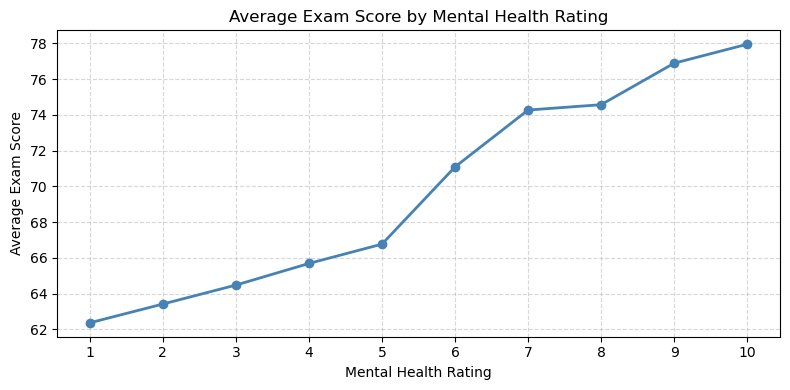

In [11]:
EDA1.Mentalhealth_ExamScore(st_habits1)

### Inference : Students performance with higher mental health rating is relatively higher compared to students with
### lower mental health rating.

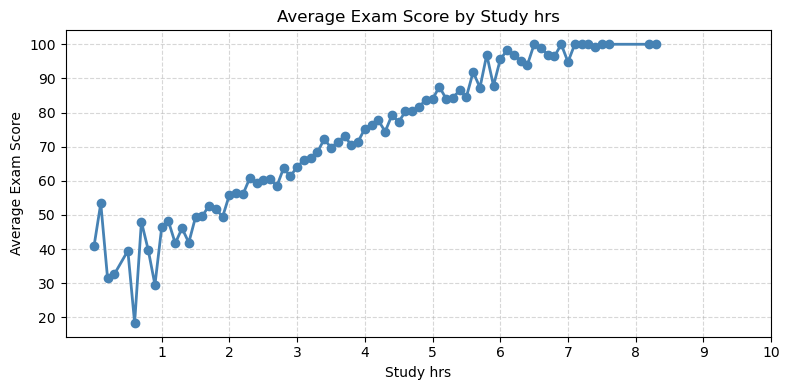

In [12]:
EDA1.Studyhrs_ExamScore(st_habits1)

### Inference : Students with higher study hrs have performed higher than students with lower study hrs and the curve plateaus around 7hrs

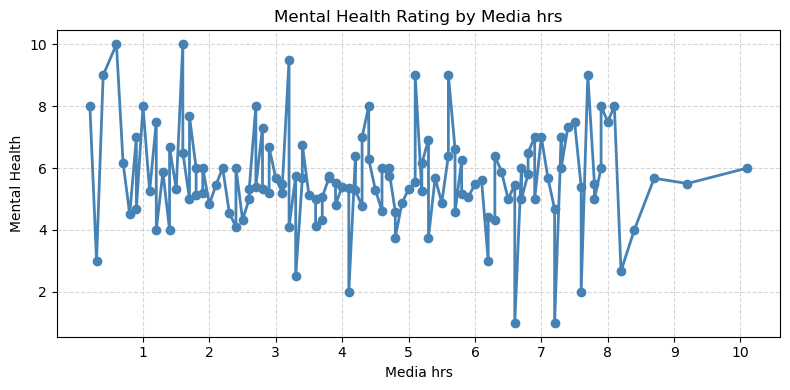

In [13]:
EDA1.mediahrs_mentalhealth(st_habits1)

### Inference:There is a volatile & non-linear realtionship between media hrs & Mental health 

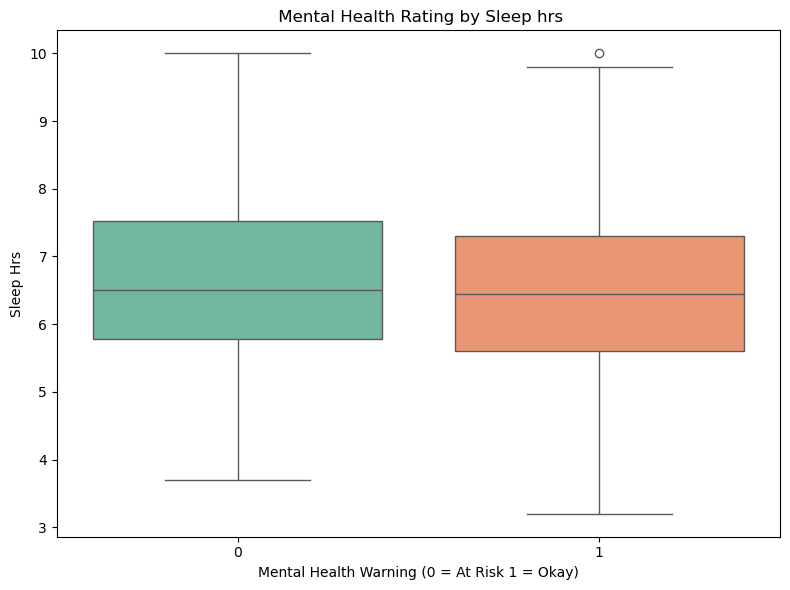

In [14]:
EDA1.sleep_mentalhealth(st_habits1)

### Inference : There is no significant difference in sleep hrs between at risk and okay students.Both category of student's sleep hrs 
### lie in the range of 5.5 to 7.5 hrs.

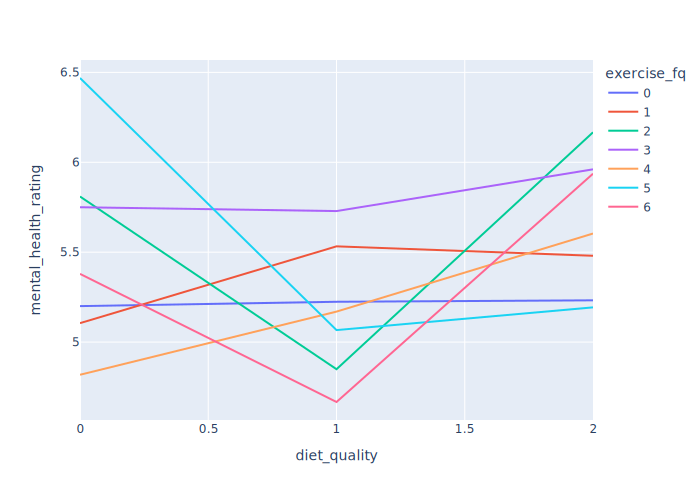

In [15]:
EDA1.mentalhealth_Diet_Exercise(st_habits1)

### Inference : Students with good diet quality (2) have stronger mental health ratings
### Inference : Students with Exercise fq 4 & 6 have gradual rise in their mental health rating .It also suggest that good diet habits 
### may impact their well being.


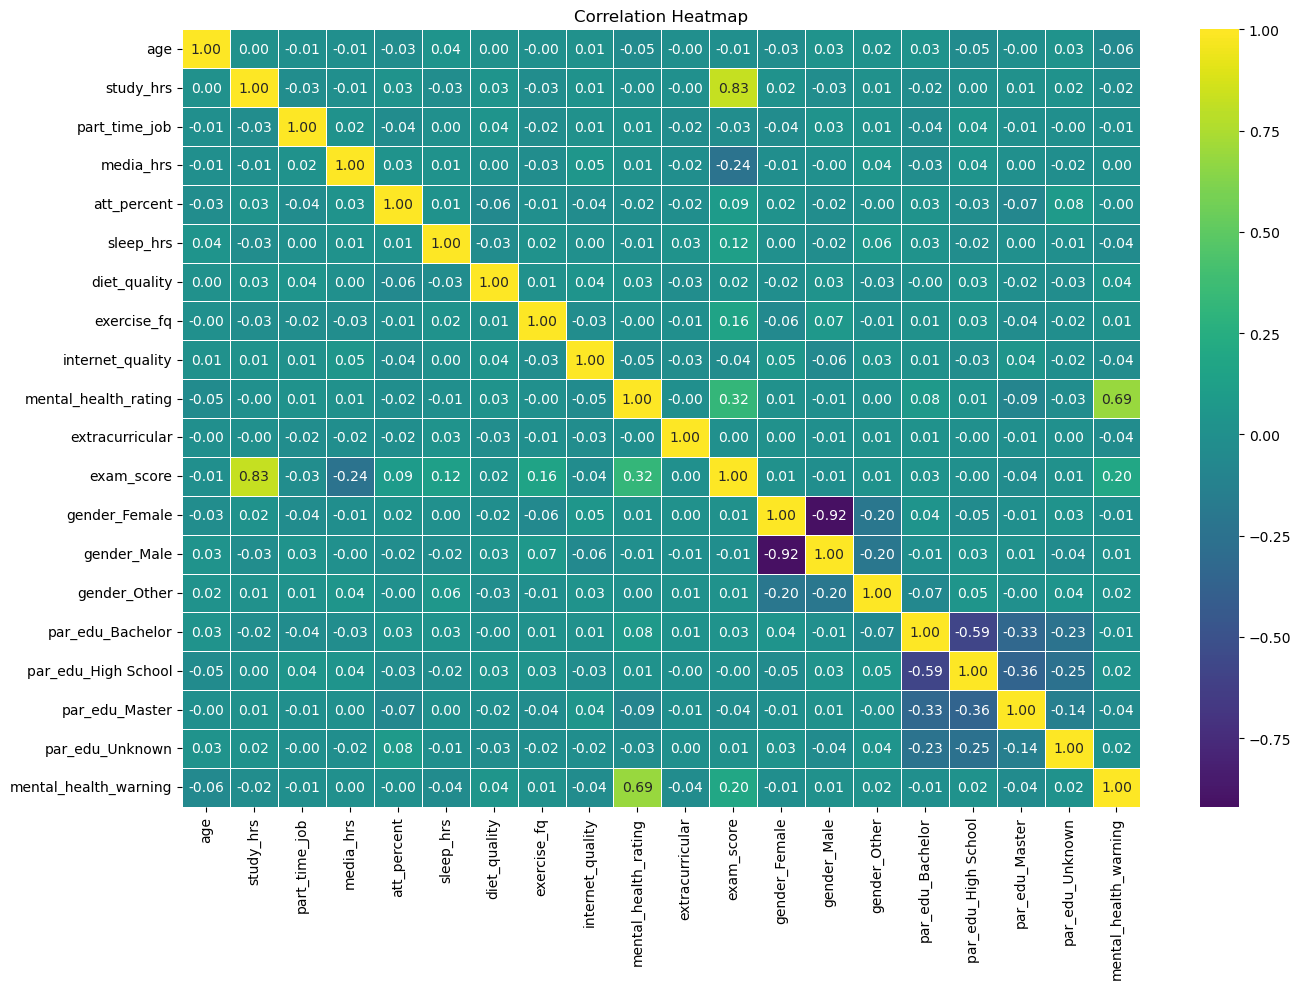

In [16]:
EDA1.correlation_heatmap(st_habits1)

| Correlation                                   | Interpretation                                         |
| --------------------------------------------- | --------------------------------------------           |
| mental_health_rating & exam_score = +0.32     | Good Mental health linked to better exam scores        |
| mental_health_rating & sleep_hrs  = -0.01     | Poor sleep may have impact on Mental health            |
| mental_health_rating & diet       = +0.03     | Good diet may impact mental health positively          |
| exam_score & study_hours          = +0.83     | More study hrs linked to higher scores                 |
| exam_score & media_hours          = -0.24     | More social media linked to lower scores               |
| sleep_hrs & exam_score            = +0.12     | More Sleep may increase exam scores                    |
| exercise & exam_score             = +0.16     | Exercise frequency increases exam scores significantly |


### Conclusion : No single feature separates at-risk students clearly , but the combination of features will !!!!!!